<a href="https://colab.research.google.com/github/VarvaraSharutina/bioinfo/blob/main/bionf_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Математические методы биоинформатики

### Home work 5. Задача обучения с учителем - классификация.

### Задание.

В файле *gliomas_proteomics.xlsx* представлены протеомные данные пациентов с опухолями головного мозга. Необходимо разработать классификатор для предсказания одного из трех подтипов опухоли (целевая переменная *diagnoses.primary_diagnosis*): *'Oligodendroglioma, anaplastic'*, *'Astrocytoma, anaplastic'* или *'Mixed glioma'*.

Выполните следующие задания:

1) Проведите полный цикл предварительной обработки данных.  

2) Сформируйте два подмножества признаков: subset1 (все признаки) и subset2 (признаки, статистически значимо отличающиеся между классами в результате множественного тестирования).

3) Примените рассмотренные на лекции модели классификации (логистическая регрессия, kNN, SVM, дерево решений, случайный лес, экстремально случайный лес) к полученным наборам признаков (subset1 и subset2).  
- Выясните, какие метрики качества классификации предпочтительно использовать в условиях дисбаланса классов, выберите 3 основные.  
- Для каждой модели выполните подбор гиперпараметров с помощью Байесовской оптимизации.  
- Сформируйте таблицу значений выбранных метрик качества для рассматриваемых моделей и подмножеств признаков. Метрики должны быть вычислены на обучающей выборке с помощью кросс-валидации. Выберите лучшую модель.

4) Для лучшей модели вычислите метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы.

In [157]:
!pip install scikit-optimize

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from skopt import BayesSearchCV
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_predict


url = "https://raw.githubusercontent.com/VarvaraSharutina/bioinfo/main/gliomas_proteomics.xlsx"
data_raw = pd.read_excel(url)

In [159]:
data_raw

,cases.submitter_id,demographic.age,demographic.gender,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,...,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1,diagnoses.primary_diagnosis
0,TCGA-FG-A4MY,44,0.0,0.069264,0.372950,-0.519320,-0.60410,-0.379530,0.494390,-0.210410,...,-0.27421,-0.275680,-1.09340,-0.068482,-0.079755,-0.261117,-0.671932,-1.558470,0.392366,Mixed glioma
1,TCGA-DB-A4X9,33,0.0,0.182310,0.338840,-0.035191,-0.53742,-0.058336,-0.459420,-0.375550,...,-0.20808,-0.045655,-1.25390,-0.138460,-0.024303,-0.180114,-0.448852,-1.696286,0.763768,Mixed glioma
2,TCGA-FG-7634,28,1.0,0.299810,0.262360,-0.553070,-0.35459,-0.068374,0.635260,-0.113780,...,-0.38825,-0.504620,-1.15610,-0.110080,0.010908,-0.350363,-0.438118,-1.272206,0.418899,"Oligodendroglioma, NOS"
3,TCGA-HT-7467,54,1.0,0.315760,0.130070,-0.151660,-1.25110,-0.198960,-0.136750,-0.124820,...,-0.50708,-0.604310,-1.63970,-0.262980,-0.047955,-0.668674,-1.067962,-1.451437,-0.318740,"Oligodendroglioma, NOS"
4,TCGA-HT-7689,58,0.0,0.186980,0.299770,-0.455300,-0.54562,-0.140740,0.637500,-0.059809,...,-0.48420,-0.442580,-1.33540,-0.380810,-0.158720,-0.429271,-0.728330,-1.444349,-0.157615,"Oligodendroglioma, NOS"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,TCGA-QH-A6CX,66,1.0,0.092804,0.077194,-0.402860,-0.72787,-0.386700,0.022955,-0.238490,...,-0.43153,-0.332780,-0.86409,-0.250640,-0.064918,-0.523537,-0.624028,-1.419079,0.072489,"Astrocytoma, NOS"
425,TCGA-HT-7877,20,0.0,0.201540,0.176760,0.054317,-1.00930,0.088261,0.776160,-0.199040,...,-0.55137,-0.637210,-1.74160,-0.277490,0.027611,-0.608156,-0.878140,-1.623911,-0.107285,"Oligodendroglioma, NOS"
426,TCGA-FG-8187,31,1.0,0.669430,0.160690,0.471790,-0.70687,0.118910,0.180140,-0.054228,...,-0.56844,-0.461280,-1.05210,-0.639230,-0.090217,-0.919737,-1.113103,-1.509356,-0.104579,Mixed glioma
427,TCGA-DB-A75M,47,1.0,0.183000,0.081269,-0.307570,-0.64397,-0.188450,0.470360,-0.385000,...,-0.41464,-0.241380,-0.66450,-0.654090,0.083094,-0.525568,-0.614663,-1.560642,0.364697,"Astrocytoma, NOS"


1. Проведите полный цикл предварительной обработки данных.

In [160]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Columns: 491 entries, cases.submitter_id to diagnoses.primary_diagnosis
dtypes: float64(488), object(3)
memory usage: 1.6+ MB


In [161]:
print(data_raw.select_dtypes(include=['object']).columns.tolist())

['cases.submitter_id', 'demographic.age', 'diagnoses.primary_diagnosis']


In [162]:
#Удалим cases.submitter_id
data_raw=data_raw.drop('cases.submitter_id', axis=1)

# Посмотрим наличие проблематичных значений в demographic.age
print(data_raw['demographic.age'].value_counts())

# Преобразуем проблематичные значения в NaN, остальные в числа
data_raw['demographic.age'] = pd.to_numeric(data_raw['demographic.age'], errors='coerce')

demographic.age
38     20
33     16
30     16
31     14
36     14
37     13
34     13
29     13
47     12
41     12
39     11
32     11
35     11
53     10
51     10
58     10
43     10
54     10
40      9
48      9
62      9
44      9
52      8
60      8
59      8
26      7
46      7
42      7
25      7
50      7
57      6
27      6
28      6
61      6
24      6
56      6
49      6
55      6
22      5
45      5
20      5
23      5
63      4
66      4
74      4
21      4
64      4
73      3
67      3
69      2
71      2
70      2
17      1
75      1
86      1
68      1
18      1
'--     1
14      1
65      1
Name: count, dtype: int64


In [163]:
# Поиск неявных дубликатов
print(data_raw['demographic.gender'].value_counts())
print("-" * 40)
print(data_raw['diagnoses.primary_diagnosis'].value_counts())
print("-" * 40)

# Удалим лишнее из целевой перменной
data_raw = data_raw[data_raw['diagnoses.primary_diagnosis'].isin(['Oligodendroglioma, anaplastic','Astrocytoma, anaplastic','Mixed glioma'])]
print("\nЗначения целевой переменной после обработки")
print(data_raw['diagnoses.primary_diagnosis'].value_counts())
print(data_raw.shape)

demographic.gender
1.0    237
0.0    191
Name: count, dtype: int64
----------------------------------------
diagnoses.primary_diagnosis
Mixed glioma                     114
Oligodendroglioma, NOS           103
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Astrocytoma, NOS                  47
Not Reported                       1
Name: count, dtype: int64
----------------------------------------

Значения целевой переменной после обработки
diagnoses.primary_diagnosis
Mixed glioma                     114
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Name: count, dtype: int64
(278, 490)


In [164]:
# Поиск полных дубликатов
duplicates = data_raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

# Поиск частичных дубликатов
dw=data_raw.drop('diagnoses.primary_diagnosis', axis=1)
duplicates = dw.duplicated().sum()
print(f"Количество частичных дубликатов: {duplicates}")

Количество полных дубликатов: 0
Количество частичных дубликатов: 0


In [165]:
# Обработка пропусков
data_raw.isnull().sum()[data_raw.isnull().sum() > 0]

,0
ALPHACATENIN,109
AXL,278
CA9,278
CASPASE9,278
COMPLEXIISUBUNIT30,278
CTLA4,278
E2F1,278
ENY2,278
EZH2,278
GATA6,278


In [166]:
# Удалим признаки, содержащие более 20% пропусков
cols_for_delete=data_raw.isnull().sum()[data_raw.isnull().sum() > 0].index.tolist()
data_raw=data_raw.drop(cols_for_delete, axis=1)
data_raw.isnull().sum()[data_raw.isnull().sum() > 0]

,0


In [167]:
df=data_raw
X=df.drop('diagnoses.primary_diagnosis', axis=1)
y=df['diagnoses.primary_diagnosis'] # целевая переменная

# Кодирование целевой метки
label_encoder=LabelEncoder()
y_enc=label_encoder.fit_transform(y)
classes = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(classes)

# Разделение на тестовую и обучающую выборки
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_enc, test_size=0.2, random_state=42)

{'Astrocytoma, anaplastic': np.int64(0), 'Mixed glioma': np.int64(1), 'Oligodendroglioma, anaplastic': np.int64(2)}



CYCLINB1
Границы: [-2.64, -0.99]
Количество выбросов: 21 
Минимальное значение выброса: -2.7268
Максимальное значение выброса: 0.4265


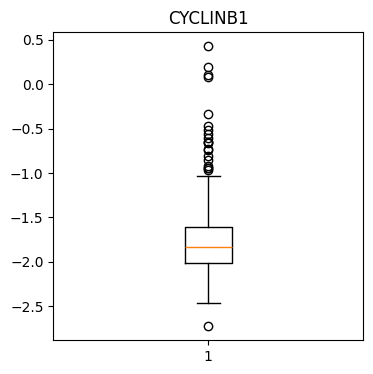


EGFR
Границы: [-0.63, 2.21]
Количество выбросов: 26 
Минимальное значение выброса: -0.66579
Максимальное значение выброса: 4.3015


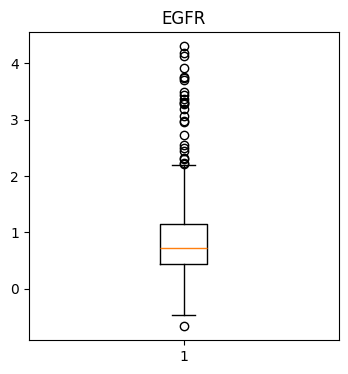


EGFR_pY1068
Границы: [-0.59, 1.73]
Количество выбросов: 25 
Минимальное значение выброса: 1.7731
Максимальное значение выброса: 8.3982


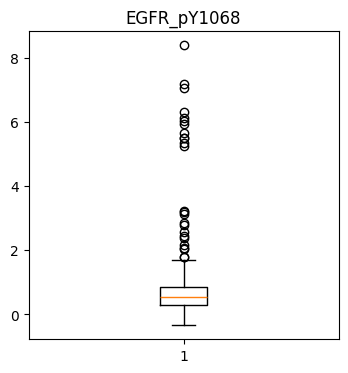


HER2
Границы: [-1.63, -0.35]
Количество выбросов: 32 
Минимальное значение выброса: -2.0947
Максимальное значение выброса: 0.83153


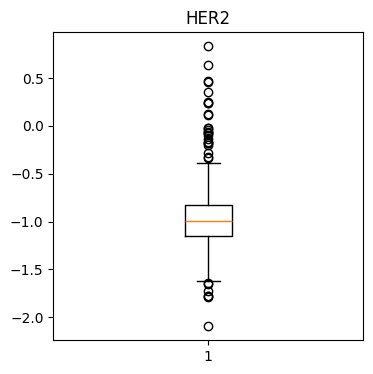


HER2_pY1248
Границы: [-0.41, 0.49]
Количество выбросов: 25 
Минимальное значение выброса: 0.48893
Максимальное значение выброса: 4.2648


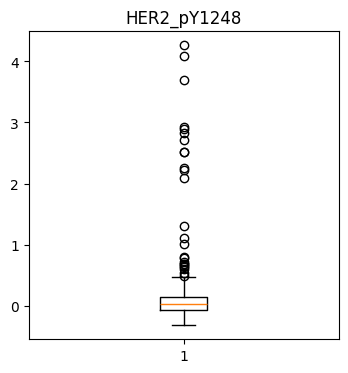


PAI1
Границы: [-1.48, 0.13]
Количество выбросов: 23 
Минимальное значение выброса: 0.1539
Максимальное значение выброса: 3.0154


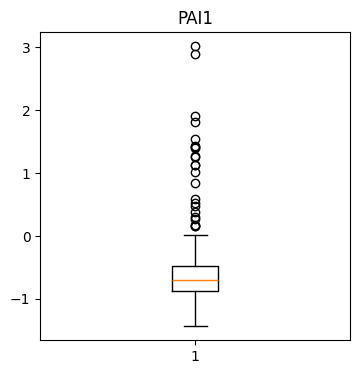


PAR
Границы: [-3.54, -1.32]
Количество выбросов: 31 
Минимальное значение выброса: -1.314142
Максимальное значение выброса: 2.485712


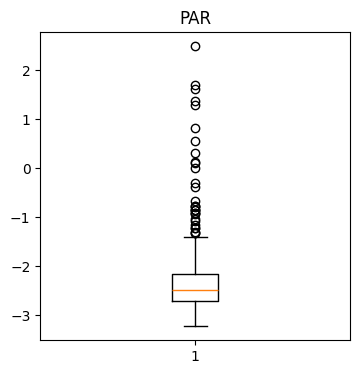


SHC_pY317
Границы: [-0.22, 0.56]
Количество выбросов: 21 
Минимальное значение выброса: -0.33083
Максимальное значение выброса: 1.9039


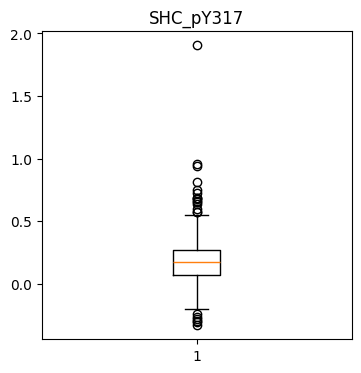


SHP2_pY542
Границы: [-0.77, 1.73]
Количество выбросов: 21 
Минимальное значение выброса: -1.0449
Максимальное значение выброса: 5.8503


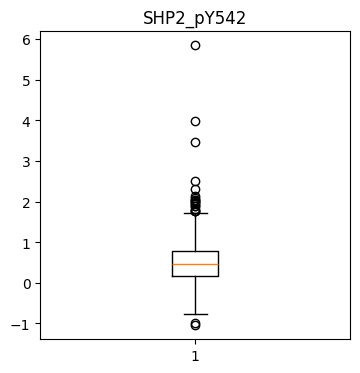


Wee1
Границы: [-1.81, 0.02]
Количество выбросов: 23 
Минимальное значение выброса: 0.02429887
Максимальное значение выброса: 1.051081


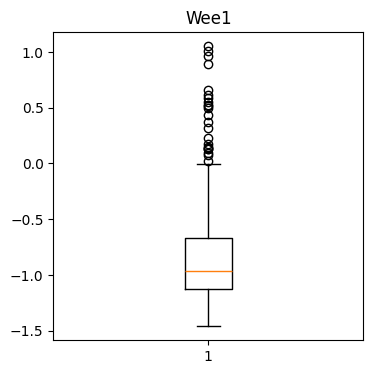

In [168]:
# Анализ выбросов
all_cols = data_raw.columns.tolist()
categorial_cols=['demographic.gender']
target_var=['diagnoses.primary_diagnosis']
numeric_cols = [col for col in all_cols if col not in categorial_cols+target_var]

def analysis_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    mini = Q1 - 1.5 * IQR
    maxi = Q3 + 1.5 * IQR
    outliers = data[(data[column] < mini) | (data[column] > maxi)]
    return outliers, mini, maxi

for col in numeric_cols:
    outliers, min, max = analysis_outliers(df, col)
    if len(outliers) > 20:
      print(f"\n{col}")
      print(f"Границы: [{min:.2f}, {max:.2f}]")
      print(f"Количество выбросов: {len(outliers)} ")
      print(f"Минимальное значение выброса: {outliers[col].min()}")
      print(f"Максимальное значение выброса: {outliers[col].max()}")
      # print(f"Bыбросы: {outliers[col].tolist()}")
      plt.figure(figsize=(4, 4))
      plt.boxplot(df[col])
      plt.title(col)
      plt.show()

С выбросами было принято решение ничего не делать, так как самое большое количество выбросов среди признаков составляет 32 образца (примерно 12% от всех образцов), из-за чего удаление признака приведёт к потере информации. Но если удалить чисто образцы, которые являются выбросами, мы также потеряем очень много информации (останется всего 3 образца из 278)

In [169]:
# z-нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Сформируйте два подмножества признаков: subset1 (все признаки) и subset2 (признаки, статистически значимо отличающиеся между классами в результате множественного тестирования).

In [170]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

subset1 = numeric_cols +categorial_cols
print(f"Кол-во признаков в subset1: {len(subset1)}")

subset2=[]
p_values = []
features = []
X_train_orig = df.drop(columns=['diagnoses.primary_diagnosis']).loc[X_train.index]

for col in categorial_cols:
  observed = pd.crosstab(X_train_orig[col], y_train)
  groups = [X_train_orig[col][y_train == val] for val in np.unique(y_train)]
  _, p_val, _, _ = stats.chi2_contingency(observed)
  p_values.append(p_val)
  features.append(col)

for col in numeric_cols:
  groups = [X_train_orig[col][y_train == val] for val in np.unique(y_train)]
  stat, p_val = kruskal(*groups)
  p_values.append(p_val)
  features.append(col)

_, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
subset2 = [col for col, pval in zip(features, pvals_corrected)if pval < 0.05]
print('\nТаблица сопряженности:')
print(observed)

print(f"\nКол-во признаков в subset2: {len(subset2)}")

Кол-во признаков в subset1: 458

Таблица сопряженности:
col_0                0   1   2
demographic.gender            
0.0                 36  44  20
1.0                 43  52  27

Кол-во признаков в subset2: 122


3. Примените рассмотренные на лекции модели классификации (логистическая регрессия, kNN, SVM, дерево решений, случайный лес, экстремально случайный лес) к полученным наборам признаков (subset1 и subset2).

In [171]:
warnings.filterwarnings('ignore')
scoring = {'f1_weighted': make_scorer(f1_score, average='weighted'),'balanced_accuracy': make_scorer(balanced_accuracy_score),'roc_auc_ovr': 'roc_auc_ovr'}

models = {
    'Logistic Regression': (LogisticRegression(),
                            {'C': (0.001, 10, 'log-uniform') }),
    'kNN': (KNeighborsClassifier(),
         {'n_neighbors': (2, 20),
          'p': [1, 2]}),
    'SVM': (SVC(probability=True),
         {'C': (0.001, 10.0, 'log-uniform'),
          'kernel': ['linear', 'rbf']}),
    'DecisionTree': (DecisionTreeClassifier(),
                      {'max_depth': (2, 20),
                        'min_samples_split': (2, 20),
                        'min_samples_leaf': (1, 10),
                        'max_features': ['sqrt', 'log2', None]}),
    'RandomForest': (RandomForestClassifier(),
                      {'n_estimators': (10, 100),
                      'max_depth': (2, 20),
                      'min_samples_split': (2, 20),
                      'min_samples_leaf': (1, 10),
                      'max_features': ['sqrt', 'log2', None]}),
    'ExtraTrees': (ExtraTreesClassifier(),
                  {'n_estimators': (10, 100),
                  'max_depth': (2, 20),
                  'min_samples_split': (2, 20),
                  'min_samples_leaf': (1, 10),
                  'max_features': ['sqrt', 'log2', None]}),
        }

results = []
best_models = {}
for subset_name, subset_cols in [('subset1', subset1), ('subset2', subset2)]:

    X_tr = X_train_scaled_df[subset_cols]

    for model_name, (model, params) in models.items():
      bayes_search = BayesSearchCV(model, params, n_iter=20, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)
      bayes_search.fit(X_tr, y_train)
      best_model = bayes_search.best_estimator_
      best_models[(model_name, subset_name)] = best_model

      cv_res = cross_validate(best_model,X_tr,y_train,cv=5,scoring=scoring,n_jobs=-1)

      results.append({
          'Model': model_name,
          'Features': subset_name,
          'F1_weighted': cv_res['test_f1_weighted'].mean(),
          'Balanced Accuracy': cv_res['test_balanced_accuracy'].mean(),
          'ROC_AUC_OVR': cv_res['test_roc_auc_ovr'].mean(),
      })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by='F1_weighted', ascending=False))

                  Model Features  F1_weighted  Balanced Accuracy  ROC_AUC_OVR
8                   SVM  subset2     0.610260           0.581813     0.784034
2                   SVM  subset1     0.589211           0.560789     0.737610
5            ExtraTrees  subset1     0.580082           0.563012     0.744797
9          DecisionTree  subset2     0.575173           0.585867     0.707023
6   Logistic Regression  subset2     0.570015           0.537481     0.761628
10         RandomForest  subset2     0.562348           0.531140     0.760502
11           ExtraTrees  subset2     0.557546           0.520609     0.755920
0   Logistic Regression  subset1     0.544737           0.521530     0.710057
4          RandomForest  subset1     0.537672           0.499683     0.734212
3          DecisionTree  subset1     0.531703           0.522544     0.660604
7                   kNN  subset2     0.529113           0.512602     0.727100
1                   kNN  subset1     0.508071           0.481711

Лучшей моделью оказалась SVM на subset2

4. Для лучшей модели вычислите метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы.

F1_weighted: 0.5725848939512453
Balanced Accuracy: 0.5821661998132587
ROC_AUC_OVR: 0.7744139131136034


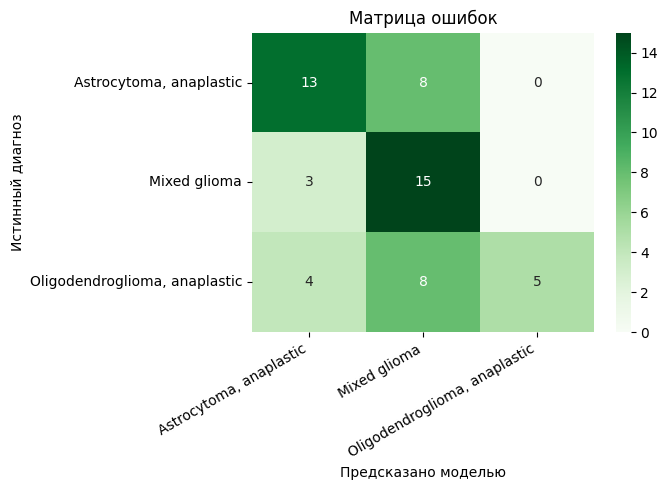

Astrocytoma, anaplastic: Чувствительность = 0.619, Специфичность = 0.800
Mixed glioma: Чувствительность = 0.833, Специфичность = 0.579
Oligodendroglioma, anaplastic: Чувствительность = 0.294, Специфичность = 1.000


In [172]:
best_model = best_models[('SVM', 'subset2')]
X_tr = X_train_scaled_df[subset2]
X_te = X_test_scaled_df[subset2]
best_model.fit(X_tr, y_train)
y_pred_test = best_model.predict(X_te)
y_proba_test = best_model.predict_proba(X_te)

# Вычислим метрики для лучшей модели
f1 = f1_score(y_test, y_pred_test, average='weighted')
bal_acc = balanced_accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
print(f"F1_weighted: {f1}")
print(f"Balanced Accuracy: {bal_acc}")
print(f"ROC_AUC_OVR: {roc_auc}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказано моделью')
plt.ylabel('Истинный диагноз')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Вычислим специфичность и чувствительность для каждого класса
n_classes = len(label_encoder.classes_)
sensitivity = []
specificity = []
for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    TPR = TP / (TP + FN) # чувствительность (Recall)
    TNR = TN / (TN + FP) # специфичность
    sensitivity.append(TPR)
    specificity.append(TNR)
for i in range(n_classes):
    print(f"{label_encoder.classes_[i]}: Чувствительность = {sensitivity[i]:.3f}, Специфичность = {specificity[i]:.3f}")

Несмотря на то, что модель SVM на subset2 была выбрана лучшей среди остальных вариантов, она показала не самые хорошие результаты на тестовой выборке.

По матрице ошибок и метрикам качества можно заметить, что среди Astrocytoma, anaplasti модель находит только 62% реальных случаев, и другие классы ошибочно предсказывают как этот.

Mixed glioma показала хорошие результаты тем, что модель находит 83% реальных случаев, но при этом модель часто путает этот класс с другими (16 случаев она отнесла к этому классу неверно, 15 предсказала правильно)

Oligodendroglioma, anaplastic несмотря на отличный показатель специфичности (модель почти никогда не предсказвает ошибочно), у неё очень плохая чувствительность, то есть модель находит всего 29% реальных случаев, остальные относит ложно к другим классам.

Можно сделать вывод, что выбранная модель далека от надежной.
